### Red wine dataset classification, dataset optimization attempts, version 3

This the final version for this optimization in this course, but it shows as a nice showcase how you can apply various methods in order to boost accuracy considerable, in this case over +20% from original!

In [134]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import TomekLinks
from sklearn.model_selection import train_test_split
from sklearn import metrics
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
import numpy as np
import random
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.preprocessing import LabelEncoder

# pip install xgboost
from xgboost import XGBClassifier

In [135]:
# we lock down the randomness of all tools
# because we want our clustering etc. optimizations
# to remain constant every time we run it
# random_seed = 789765555, 192987423
random_seed = 789765555

random.seed(random_seed)
np.random.seed(random_seed)

# if you use neural networks with TensorFlow, remember also:
# tf.random.set_seed(random_seed)

**IDEA: Lock down the random seed for reproducibility**

In [136]:
df = pd.read_csv("winequality-red.csv")

### Optimizations - SMOTE

In [137]:
# Separate features and target
X = df.drop('quality', axis=1)
y = df['quality']

# Apply SMOTE to the dataset
smote = SMOTE()
X_resampled, y_resampled = smote.fit_resample(X, y)

# Combine resampled features and target into a new DataFrame
df_resampled = pd.DataFrame(X_resampled, columns=X.columns)
df_resampled['quality'] = y_resampled

# # Display original class distribution
# print("Original class distribution:")
# print(df['quality'].value_counts())

# # Visualize original distribution
# sns.countplot(x='quality', data=df)
# plt.title('Original Class Distribution')
# plt.show()

# # Display new class distribution
# print("New class distribution after SMOTE:")
# print(df_resampled['quality'].value_counts())

# # Visualize new distribution
# sns.countplot(x='quality', data=df_resampled)
# plt.title('Class Distribution After SMOTE')
# plt.show()

synthetic_df = df_resampled[~df_resampled.isin(df).all(axis=1)]

# use the resampled DataFrame
# df = df_resampled
authentic_df = df.copy()
df = synthetic_df


**Use only real wines for testing dataset to get more realistic metrics**

In [138]:
# THIS IS NOT OPTIMAL SOLUTION FOR THIS
# REWRITE LATER 

# max threshold for majority classes
threshold = 53

# temporary list to containe sample rows
sampled_data = []

for quality, group in authentic_df.groupby('quality'):
    # if a minority group, just add all the data
    if len(group) <= threshold:
        sampled_data.append(group)
    else:
        sampled_data.append(group.sample(threshold))


# combine all data in the sample list
authentic_sample = pd.concat(sampled_data)

# drop the selected data from the original data
#print(len(authentic_df))
authentic_df = authentic_df.drop(authentic_sample.index)
#print(len(authentic_df))

# reset indexes
authentic_sample = authentic_sample.reset_index(drop=True)
authentic_df = authentic_df.reset_index(drop=True)

df = pd.concat([df, authentic_df])
df = df.reset_index(drop=True)

# remove any rows in df_train that also appear in df_other
df_clean = df.merge(authentic_sample, how='outer', indicator=True)
df_clean = df_clean[df_clean['_merge'] == 'left_only'].drop(columns=['_merge'])
df = df_clean

In [139]:
# the idea is this:
from sklearn.mixture import GaussianMixture
from sklearn.cluster import KMeans

scaler = StandardScaler()
X_scaled = scaler.fit_transform(df.drop('quality', axis=1))

# use KMeans to cluster these wines into clusters
# => try to find a separation where the algorithm recognizes the wines
# without knowing the actual quality level
# clusterer = KMeans(n_clusters=8, init="k-means++", tol=1e-10, n_init=10)

clusterer = GaussianMixture(n_components=8)
labels = clusterer.fit_predict(X_scaled)

# save cluster back to dataset
df['cluster'] = labels

X_authentic_scaled = scaler.transform(authentic_sample.drop("quality", axis=1))
labels = clusterer.predict(X_authentic_scaled)
authentic_sample['cluster'] = labels

In [140]:
# you can try to get a clear clustering that helps the model eventually
cluster_counts = df.groupby(['quality', 'cluster']).size().unstack(fill_value=0)
print(cluster_counts)

cluster   0    1    2    3    4    5    6    7
quality                                       
3        10   18    0    0    1  243  399    0
4        53  278    0  153  144    0    0    0
5        91   73    0  334  110    0    0    0
6        58   65    0  280  213    0    0    0
7        29   24    0  176  365    0    0    3
8         0    0  351   24   99    0    0  172


### Since this dataset suffers from overlapping between qualities 5 and 6 (middle range wines), TomekLinks is probably a good idea

In [141]:
# initialize TomekLinks
# TomekLinks is used to reduce data overlap throughout the dataset
# howewer, we can't really configure its parameters
tomek = TomekLinks()

# X/y -split
X = df.drop("quality", axis=1)
y = df['quality']

# create new resampled versions of X and y
X_resampled, y_resampled = tomek.fit_resample(X, y)

# re-create a new DataFrame
df_resampled = pd.DataFrame(X_resampled, columns=X.columns)
df_resampled['quality'] = y_resampled

df = df_resampled

### Add some slight outlier removal (Isolation Forest)

In [142]:
# can process the whole dataset 
# and compares variables to each other instead
# of focusing on outliers on a single variable
from sklearn.ensemble import IsolationForest
import pandas as pd

# adjust the contamination rate as you see fit
# for example, if you expect 5% of the data to be outliers
# you can use 0.05 etc. 

# basically, this is how aggressive Isolation Forest will be
# increase if you think you need to detect more outliers
# decrease if you need less outliers
iso = IsolationForest(contamination=0.015) 

# fit isolation forest
y_pred = iso.fit_predict(df)

# separate outliers and inliers into separate DataFrames
outliers = df[y_pred != 1]
inliers = df[y_pred == 1]

print(f"Inliers: {len(inliers)}")
print(f"Outliers: {len(outliers)}")

# use the inliers as the new DataFrame
df = inliers

Inliers: 3544
Outliers: 54


### Use clustering to help out the model in differentiating between the qualities (especially with the qualities 5 and 6)

In [143]:
df

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,cluster,quality
0,4.825753,0.542575,0.140325,2.177401,0.056709,9.161017,64.741996,0.993842,3.880650,0.570320,12.887147,3,4
1,4.900000,0.420000,0.000000,2.100000,0.048000,16.000000,42.000000,0.991540,3.710000,0.740000,14.000000,3,7
2,4.962362,0.534304,0.153814,2.109536,0.057719,8.286075,65.953583,0.993778,3.833249,0.562861,12.728103,3,4
3,5.000000,0.380000,0.010000,1.600000,0.048000,26.000000,60.000000,0.990840,3.700000,0.750000,14.000000,3,6
4,5.000000,0.740000,0.000000,1.200000,0.041000,16.000000,46.000000,0.992580,4.010000,0.590000,12.500000,3,6
...,...,...,...,...,...,...,...,...,...,...,...,...,...
3592,15.000000,0.210000,0.440000,2.200000,0.075000,10.000000,24.000000,1.000050,3.070000,0.840000,9.200000,4,7
3593,15.047055,0.671176,0.740252,4.114709,0.096643,6.197480,42.802520,1.003003,2.973698,0.689874,10.963024,4,7
3594,15.383847,0.679596,0.752280,3.862115,0.098688,6.077198,42.922802,1.003123,2.959264,0.683860,11.107363,4,7
3595,15.600000,0.645000,0.490000,4.200000,0.095000,10.000000,23.000000,1.003150,2.920000,0.740000,11.100000,4,5


**Add PCA and compress the data slightly**

In [144]:
from sklearn.decomposition import PCA
# from sklearn.decomposition import KernelPCA

# X/y -split and scale the values
X = df[['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar',
       'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density',
       'pH', 'sulphates', 'alcohol', 'cluster']]

y = df['quality']

# create a separate scaler for PCA since we already
# have a different scaler for clustering
scaler_pca = StandardScaler()
X_scaled = scaler_pca.fit_transform(X)

# define amount of PCA-variables => principal components
num_components = 11

# train the PCA -model
pca = PCA(n_components=num_components)

# you can also experiment with KernelPCA, but then comment out the variance metrics
# pca = KernelPCA(n_components=num_components, kernel='rbf', gamma=0.35, fit_inverse_transform=True)
X_pca = pca.fit_transform(X_scaled)

# some basic metrics
explained_variance_ratio = pca.explained_variance_ratio_
print(f"Explained variance ratio with {num_components} components, by each component:\n{explained_variance_ratio}")
print(f"\nExplained variance ratio with {num_components} components, total result:\n{sum(explained_variance_ratio)}")

# 0.798 ~~ 80% of data preserved, which means we lost 20% of variance in the process
# aim to have less than 10% lost, or even less than 5% lost

X_reconstructed = pca.inverse_transform(X_pca)

# this is where we branch off the original PCA example

# we also have to process the test data
X_test = authentic_sample[['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar',
       'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density',
       'pH', 'sulphates', 'alcohol', 'cluster']]

# scale the test data 
X_test_scaled = scaler_pca.transform(X_test)
X_test_pca = pca.transform(X_test_scaled)
X_test_reconstructed = pca.inverse_transform(X_test_pca)


Explained variance ratio with 11 components, by each component:
[0.27360313 0.20328808 0.13830656 0.09577    0.08835404 0.06475458
 0.04485018 0.02893973 0.02470367 0.02246417 0.01023282]

Explained variance ratio with 11 components, total result:
0.9952669632557969


### Train/test -split

In [145]:
# X = df.drop("quality", axis=1)
# y = df['quality']

In [146]:
# categories = list(np.unique(df['quality']))


# # encode the target from original 3, 4, 5, 6, 7, 8 to 0, 1, 2, 3, 4, 5
# le = LabelEncoder()
# # y = le.fit_transform(y)

# # stratify can be used to ensure data balance between train/test -datasets
# # X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, stratify=y)
# X_train = df.drop("quality", axis=1)
# y_train = df['quality']
# y_train = le.fit_transform(y_train)

# X_test = authentic_sample.drop("quality", axis=1)
# y_test = authentic_sample["quality"]
# y_test = le.transform(y_test)


In [147]:
categories = list(np.unique(df['quality']))

# let's encode our target from the original 3,4,5,6,7,8 to 0,1,2,3,4,5
le = LabelEncoder()
y = le.fit_transform(y)

# if bad result, consider shuffling the dataset just in case

# stratify can be used to ensure that train/test -split aims to have same distributions
# for both train and test datasets
# X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, stratify=y)

# X_reconstructed went through clustering -> scaler -> pca
X_train = X_reconstructed
y_train = y

# X_test_reconstructed went through clustering -> scaler -> pca
X_test = X_test_reconstructed

y_test = authentic_sample['quality']
y_test = le.transform(y_test)

### XGBoost classifier

In [148]:
# create XGboost model
model = XGBClassifier(
    objective="multi:softmax",
    num_class=len(categories),
    n_estimators=400,
    max_depth=7,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8
)

# fit the model / start training
model.fit(X_train, y_train)

,objective,'multi:softmax'
,use_label_encoder,None
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,0.8
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


### Metrics

In [149]:
test_predictions = model.predict(X_test)

<Axes: >

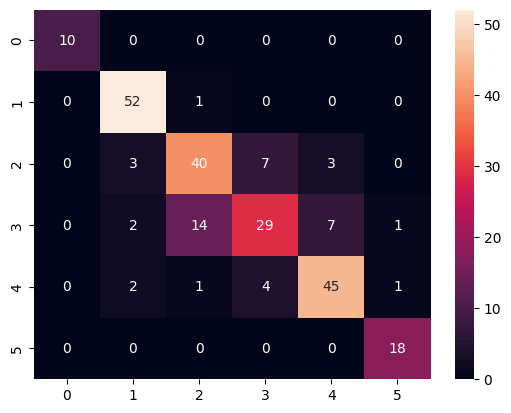

In [150]:
sns.heatmap(confusion_matrix(y_test, test_predictions), annot=True, fmt='g')


In [151]:
print(classification_report(y_test, test_predictions))

acc = accuracy_score(y_test, test_predictions)
print("\nModel overall accuracy: {:.2f}%".format(acc * 100))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       0.88      0.98      0.93        53
           2       0.71      0.75      0.73        53
           3       0.72      0.55      0.62        53
           4       0.82      0.85      0.83        53
           5       0.90      1.00      0.95        18

    accuracy                           0.81       240
   macro avg       0.84      0.86      0.84       240
weighted avg       0.80      0.81      0.80       240


Model overall accuracy: 80.83%


**USING THIS MODEL IN PRACTICE**

Our pipeline for new data:

Scaling => Clustering => PCA => put new data (wine) through the model prediction

In [152]:
# select a random wine from the authentic data
selected_index = 115

# T = transpose, converts to horizontal DataFrame
test_row = pd.DataFrame(authentic_sample.iloc[selected_index]).T

print(f"ORIGINAL CLUSTER: {int(test_row['cluster'])}")
print(f"ORIGINAL QUALITY: {int(test_row['quality'])}")
print()

test_row = test_row.drop(["cluster", "quality"], axis=1)

# this data is now in a format
# as any new unidentified wine without a quality or cluster is 
# e.g. a new bottle of wine
test_row

ORIGINAL CLUSTER: 4
ORIGINAL QUALITY: 5



C:\Users\tuomas.valtanen\AppData\Local\Temp\ipykernel_11316\1542714908.py:7: FutureWarning: Calling int on a single element Series is deprecated and will raise a TypeError in the future. Use int(ser.iloc[0]) instead
  print(f"ORIGINAL CLUSTER: {int(test_row['cluster'])}")
C:\Users\tuomas.valtanen\AppData\Local\Temp\ipykernel_11316\1542714908.py:8: FutureWarning: Calling int on a single element Series is deprecated and will raise a TypeError in the future. Use int(ser.iloc[0]) instead
  print(f"ORIGINAL QUALITY: {int(test_row['quality'])}")


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol
115,15.5,0.645,0.49,4.2,0.095,10.0,23.0,1.00315,2.92,0.74,11.1


In [153]:
# STEP 1: Scale the wine data and CLUSTERIZE
# NOTE: we only use this scaling for the clustering
# we discard the scaled values afterwards

# WE HAVE TO USE THE EXACT SAME SCALER MODEL TO SCALE THE VALUES
# AND THE SAME CLUSTERING MODEL FOR CLUSTERING
test_row_scaled = scaler.transform(test_row)
cluster_value = clusterer.predict(test_row_scaled)
print(cluster_value)

# save the result from KMeans into our new wine data row
test_row['cluster'] = cluster_value[0]

# STEP 2: Scale the wine data and PCA
test_row_scaled = scaler_pca.transform(test_row)
test_row_pca = pca.transform(test_row_scaled)
test_row_reconstructed = pca.inverse_transform(test_row_pca)

# correct cluster!:

[4]


In [154]:
result = model.predict_proba(test_row_reconstructed)
print(categories[np.argmax(result)])

# and correct quality!:

5
